# Async Execution with Tools

In [1]:
# Replace the failing notebook cell with this

import sys
from pathlib import Path

# Find project root (directory that contains "src")
cwd = Path.cwd().resolve()
project_root = next((p for p in [cwd, *cwd.parents] if (p / "src").exists()), None)

if project_root is None:
    raise ModuleNotFoundError("Could not locate project root containing a 'src' directory.")

# Ensure Python can import from project root
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
OPENAI_MODEL = "gpt-5-mini"

In [3]:
import asyncio
from typing import Annotated, Literal, TypedDict

from dotenv import find_dotenv, load_dotenv
from IPython.display import Markdown, display
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain_core.utils.function_calling import convert_to_openai_tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph, add_messages
from pydantic import BaseModel, Field

from src.scrappers.blog_posts_scrapper import BlogPostsScraper
from src.scrappers.social_media_scrapper import SocialMediaScraper
from src.scrappers.youtube_scrapper import YouTubeScrapper

In [4]:
load_dotenv(find_dotenv(), override=True)

True

In [5]:
# Initialize scrappers
blog_posts_scraper = BlogPostsScraper()
youtube_scrapper = YouTubeScrapper()
social_media_scrapper = SocialMediaScraper()

2026-03-23 21:16:27,067 | blog_posts_scrapper.py:67 | INFO | Initialized BlogPostsScraper with Tavily client.
2026-03-23 21:16:27,068 | social_media_scrapper.py:52 | INFO | Initialized SocialMediaScraper (max_results=5, days=3).


In [6]:
class InputAnalyser(TypedDict):
    user_input: str
    analyse_output: str
    platforms: Literal['youtube', 'social_media', 'blog_posts']
    messages: Annotated[list, add_messages]
    selected_platforms: list[str]
    scraped_results: dict[str, list]
    summary: str

In [7]:
class PlatformRequired(BaseModel):
    analysis: str
    platform_needed: list[Literal['youtube', 'social_media', 'blog_posts']] = Field(..., description="The values with which the the information can be extracted")

In [8]:
ANALYSIS_SYSTEM_PROMPT = """
## Role
You are an expert Query Analyst responsible for identifying the most relevant information sources for any given user query.

---

## Task
You will receive a user query as a string input. Your job is to:

1. **Analyze the Query** — Understand the intent, topic, and nature of the information the user is seeking.
2. **Identify Relevant Platforms** — Based on your analysis, determine which platforms are best suited to provide accurate and useful information for that query.

---

## Available Platforms
Select one or more platforms from the following list only:

- **YouTube** — Best for visual tutorials, demonstrations, reviews, and explainer content
- **Blog Post Platforms** (e.g., Medium, Dev.to) — Best for in-depth articles, technical write-ups, and opinion pieces
- **Social Media Platforms** (e.g., LinkedIn, X.com) — Best for industry trends, professional discussions, and real-time updates

---

## Output Format
Return your response in the following structured format:

### Analysis
Provide a clear explanation of:
- What the user is asking
- The type of content that best answers their query
- Why the selected platform(s) are appropriate

### Platforms Required
List one or more platforms from the available options that can best fulfill the user's information need.

---

## Constraints
- Only select platforms from the provided list
- You may select multiple platforms if the query benefits from diverse content types
- Keep your analysis concise but well-reasoned
"""

In [9]:
async def async_model_completion(system_prompt: str, user_prompt: str) -> PlatformRequired:

    llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)
    struct_llm = llm.with_structured_output(PlatformRequired)

    response = await struct_llm.ainvoke(
        [
            SystemMessage(content=system_prompt),
            HumanMessage(content=user_prompt)
        ]
    )
    if isinstance(response, PlatformRequired):
        return response
    return PlatformRequired.model_validate(response)

In [10]:
async def analyse_input(state: InputAnalyser) -> dict:
    user_input = state["user_input"]
    if not user_input:
        return {"analyse_output": "", "platforms": None}

    model_response = await async_model_completion(
        system_prompt=ANALYSIS_SYSTEM_PROMPT, user_prompt=user_input
    )

    if not model_response:
        return {"analyse_output": "", "platforms": None}

    if model_response:
        return {
            "analyse_output": model_response.analysis,
            "platforms": model_response.platform_needed,
        }
    else:
        return {}

In [11]:
async def build_graph():
    builder = StateGraph(InputAnalyser)
    builder.add_node("input_analyser", analyse_input)
    builder.add_edge(START, "input_analyser")
    builder.add_edge("input_analyser", END)

    graph = builder.compile()

    return graph

In [12]:
graph = await build_graph()
result = await graph.ainvoke(
        {
            "user_input": "Latest AI trends in 2024"
        }
    )

print(f"Result: {result}")

Result: {'user_input': 'Latest AI trends in 2024', 'analyse_output': 'The user is asking for the latest AI trends in 2024 — a timely overview of developments, hot topics, tools, and industry shifts. Best answers combine real-time signals (breaking news, expert commentary) with deeper explainers and demos: short-form social updates for immediacy and community insight; in-depth blog posts for technical analysis, trend essays, and long-form summaries; and YouTube videos for visual explainers, conference talks, product demos, and interviews. Selecting these platforms provides both fast updates and thoughtful, detailed context to understand and follow 2024 AI trends.', 'platforms': ['social_media', 'blog_posts', 'youtube'], 'messages': []}


### Phase-2: Tool call, Summarization and Analysis

In [13]:
@tool
async def search_youtube(query: str) -> list[dict]:
    """Search YouTube for videos and return transcripts related to the query."""
    return await youtube_scrapper.get_transcripts_for_query(query=query) # type:ignore

@tool
async def search_blog_posts(topic: str) -> list[dict]:
    """Search blog platforms like Medium and Dev.to for articles on the topic."""
    return await blog_posts_scraper.search(topic=topic) # type:ignore

@tool
async def search_social_media(topic: str) -> list[dict]:
    """Search social media platforms like LinkedIn and Reddit for posts on the topic."""
    return await social_media_scrapper.fetch_social_pulse(topic=topic) # type:ignore


tools = [search_youtube, search_blog_posts, search_social_media]
openai_tools = [convert_to_openai_tool(t) for t in tools]

### Phase-3: Sequential Pipeline — Analyse → Call Selected Tools → Summarize

In [14]:
# class AgentState(TypedDict):
#     messages: Annotated[list, add_messages]
#     selected_platforms: list[str]
#     scraped_results: dict[str, list]
#     summary: str

In [15]:
# Maps platform names (from PlatformRequired output) to scraper async callables
TOOL_REGISTRY: dict[str, dict] = {
    "youtube": {
        "fn": youtube_scrapper.get_transcripts_for_query,
        "param": "query",
    },
    "blog_posts": {
        "fn": blog_posts_scraper.search,
        "param": "topic",
    },
    "social_media": {
        "fn": social_media_scrapper.fetch_social_pulse,
        "param": "topic",
    },
}

In [16]:
async def analyse_input_node(state: InputAnalyser) -> dict:
    """Node 1: Analyse the user query and determine which platforms to scrape."""
    user_query = state["messages"][-1].content

    llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)
    struct_llm = llm.with_structured_output(PlatformRequired)

    response = await struct_llm.ainvoke(
        [
            SystemMessage(content=ANALYSIS_SYSTEM_PROMPT),
            HumanMessage(content=user_query),
        ]
    )

    if isinstance(response, PlatformRequired):
        platform_result = response
    else:
        platform_result = PlatformRequired.model_validate(response)

    print(f"[analyse_input] Platforms selected: {platform_result.platform_needed}")
    print(f"[analyse_input] Analysis: {platform_result.analysis}")

    return {"selected_platforms": platform_result.platform_needed}

In [17]:
async def call_tools_node(state: InputAnalyser) -> dict:
    """Node 2: Call only the scrapers for the selected platforms in parallel."""
    user_query = state["messages"][-1].content
    platforms = state["selected_platforms"]

    async def _call_scraper(platform: str) -> tuple[str, list]:
        entry = TOOL_REGISTRY.get(platform)
        if not entry:
            print(f"[call_tools] Skipping unknown platform: {platform}")
            return platform, []
        print(f"[call_tools] Calling scraper for: {platform}")
        result = await entry["fn"](**{entry["param"]: user_query})
        return platform, result

    results = await asyncio.gather(*[_call_scraper(p) for p in platforms])
    scraped = {platform: data for platform, data in results}

    print(f"[call_tools] Finished scraping: {list(scraped.keys())}")
    return {"scraped_results": scraped}

In [18]:
SUMMARIZE_SYSTEM_PROMPT = """
## Role
You are a Research Analyst. Your job is to read raw content from multiple platforms and produce a clear, accurate summary.

---

## Input
You will receive scraped content from one or more of these platforms:
- YouTube transcripts
- Blog posts
- Social media posts (LinkedIn, X.com)

---

## What You Must Do

1. **Summarize by Platform** — Group insights under the platform they came from so the source is always clear.
2. **Keep Key Details** — Always retain facts, names, dates, numbers, statistics, and URLs.
3. **Highlight What Matters** — Call out the most important or actionable findings.
4. **Cut the Noise** — Remove repeated information, filler text, and anything irrelevant to the topic.

---

## Output Rules
- Length: 800-1500 words
- Tone: Clear and factual (not conversational)
- Accuracy matters more than writing style
- This summary will be used for further processing, so completeness is critical

---

## Output Format

### [Platform Name]
- Key insight or finding
- Supporting detail (include any stats, dates, or URLs)

*(Repeat for each platform)*

### Top Takeaways
List the 3-5 most important findings across all platforms.

"""


MAX_CHARS_PER_PLATFORM = 12000  # ~3k tokens per platform, safe for context window


async def summarize_node(state: InputAnalyser) -> dict:
    """Node 3: Summarize all scraped results into a concise, structured summary."""
    user_query = state["messages"][-1].content
    scraped = state["scraped_results"]

    # Build per-platform content blocks, truncating if needed
    content_blocks = []
    for platform, data in scraped.items():
        raw_text = str(data)
        # if len(raw_text) > MAX_CHARS_PER_PLATFORM:
        #     raw_text = raw_text[:MAX_CHARS_PER_PLATFORM] + "\n... [truncated]"
        # content_blocks.append(f"=== {platform.upper()} ===\n{raw_text}")
        content_blocks.append(f"=== {platform.upper()} ===\n{raw_text}")

    combined_content = "\n\n".join(content_blocks)

    user_message = (
        f"User query: {user_query}\n\n"
        f"Scraped data:\n{combined_content}\n\n"
        f"Please provide a structured summary of the above data."
    )

    llm = ChatOpenAI(model=OPENAI_MODEL, temperature=0)
    response = await llm.ainvoke(
        [
            SystemMessage(content=SUMMARIZE_SYSTEM_PROMPT),
            HumanMessage(content=user_message),
        ]
    )

    print(f"[summarize] Summary generated ({len(response.content)} chars)")
    return {"summary": response.content}

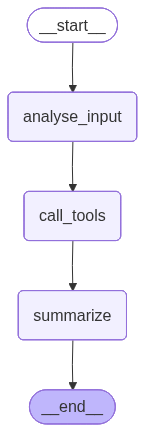

In [19]:
# Build the sequential pipeline: analyse → call_tools → summarize
builder = StateGraph(InputAnalyser)

builder.add_node("analyse_input", analyse_input_node)
builder.add_node("call_tools", call_tools_node)
builder.add_node("summarize", summarize_node)

builder.add_edge(START, "analyse_input")
builder.add_edge("analyse_input", "call_tools")
builder.add_edge("call_tools", "summarize")
builder.add_edge("summarize", END)

pipeline = builder.compile()
pipeline

In [ ]:
# Run the pipeline
pipeline_result = await pipeline.ainvoke(
    {"messages": [HumanMessage(content="Latest AI trends in 2024")]} # type:ignore
)

print("=" * 60)
print(f"Selected Platforms: {pipeline_result['selected_platforms']}")
print(f"Scraped Platforms:  {list(pipeline_result['scraped_results'].keys())}")
print("=" * 60)
print("\n--- SUMMARY ---\n")
display(Markdown(pipeline_result["summary"]))

2026-03-23 21:16:53,872 | blog_posts_scrapper.py:80 | INFO | Searching Tavily for topic: technical deep dive engineering blog Latest AI trends in 2024
2026-03-23 21:16:53,873 | social_media_scrapper.py:66 | INFO | Searching Reddit via Tavily for: site:reddit.com Latest AI trends in 2024
2026-03-23 21:16:53,875 | social_media_scrapper.py:118 | INFO | Searching LinkedIn via Tavily for: site:linkedin.com/posts Latest AI trends in 2024


[analyse_input] Platforms selected: ['blog_posts', 'social_media', 'youtube']
[analyse_input] Analysis: The user is asking for the latest AI trends in 2024—i.e., up-to-date developments, major research/industry directions, product launches, and community reactions. The best answers combine in-depth analysis (to understand implications and technical details), real-time updates (to catch breaking news and announcements), and visual explanations/demos (for clearer understanding of complex concepts). Blog posts are ideal for detailed explainers, analysis, and opinion pieces from researchers and companies. Social media (X/LinkedIn) captures fast-breaking news, community reactions, and industry signals. YouTube is useful for talks, keynotes, demos, and visual explainers that summarize trends and showcase new tools.
[call_tools] Calling scraper for: blog_posts
[call_tools] Calling scraper for: social_media
[call_tools] Calling scraper for: youtube


2026-03-23 21:16:56,076 | youtube_scrapper.py:79 | WARNING | Transcript unavailable for video SwmwLjMq9tE: 
Could not retrieve a transcript for the video https://www.youtube.com/watch?v=SwmwLjMq9tE! This is most likely caused by:

No transcripts were found for any of the requested language codes: ('en',)

For this video (SwmwLjMq9tE) transcripts are available in the following languages:

(MANUALLY CREATED)
None

(GENERATED)
 - hi ("Hindi (auto-generated)")

(TRANSLATION LANGUAGES)
None

If you are sure that the described cause is not responsible for this error and that a transcript should be retrievable, please create an issue at https://github.com/jdepoix/youtube-transcript-api/issues. Please add which version of youtube_transcript_api you are using and provide the information needed to replicate the error. Also make sure that there are no open issues which already describe your problem!
2026-03-23 21:16:56,479 | youtube_scrapper.py:125 | INFO | Fetched 4 transcripts for query 'Latest

[call_tools] Finished scraping: ['blog_posts', 'social_media', 'youtube']
[summarize] Summary generated (10457 chars)
Selected Platforms: ['blog_posts', 'social_media', 'youtube']
Scraped Platforms:  ['blog_posts', 'social_media', 'youtube']

--- SUMMARY ---



### BLOG_POSTS
- AI in 2024: A Technical Deep Dive into Emerging Trends and Technologies — Ahmed Soliman (Medium, Oct 2, 2024)
  - Key insight: Foundation models and LLMs (GPT‑4, PaLM, LLaMA) remain central; transformer architecture and parameter scaling continue to drive capabilities but full article is paywalled.
  - Supporting detail: Article published Oct 2, 2024; member-only on Medium (https://medium.com/@_asoliman/ai-in-2024-a-technical-deep-dive-into-emerging-trends-and-technologies-ac551037133a).

- Navigating the AI Landscape of 2024: Trends, Predictions and Possibilities — Vincent Koc (TDS Archive / Medium, Jan 2, 2024)
  - Key insight: 2024 is a year of operationalization — generative AI moves from hype to core strategy; major trends include foundation models, vector databases, hardware supply-chain control, XR/wearables, AI agents, expanding modalities, regulation, and purpose-built smaller models.
  - Supporting details:
    - Prediction list (1–15) includes: vector DB adoption by major data platforms; AI wearables (Humane AI Pin, Rewind); agents communicating with other agents; small, purpose-built foundational models; OpenAI “GPT marketplace” expected in 2024. Example providers named: Chroma, Weaviate, Pinecone, Qdrant, Milvus. GNoME (DeepMind) cited for materials/genomics breakthroughs. (https://medium.com/data-science/navigating-the-ai-landscape-of-2024-trends-predictions-and-possibilities-41e0ac83d68f; Jan 2, 2024)

- AI Engineer World 2024: Key Takeaways and Future Trends — Mingzhi Yu (Medium, Jul 2, 2024)
  - Key insight: Conference reporting (AI Engineer World, Jun 24–27, 2024) emphasizes that models alone are not moats; agents are promising but not yet production-ready; multimodality and open models are rising; LLM evaluation and inference/CPU optimization are critical.
  - Supporting details:
    - Models from OpenAI (GPT‑4o), Google (Gemma 2.0), Anthropic (Claude 3.5 Sonnet), Mistral, Cohere showcased.
    - Agent limitations: good at simple tasks, fail on complex workflows; suggested practices: balance reliability and flexibility, customize routing logic.
    - CPU inference/tools highlighted: LlamaFile (Mozilla) and Modular’s MAX/Mojo for faster CPU/GPU inference. (https://medium.com/@mingzhi2/ai-engineer-world-2024-key-takeaways-and-future-trends-4799f77b4c31)

- The Future is Now: A Deep Dive into AI’s Most Exciting Innovations of 2024 — Astandri Koesriputranto (Medium, Jan 30, 2024)
  - Key insight: Multimodal AI and domain applications (e.g., protein engineering) are prominent; parallel focus on both capability advances and countermeasures (deepfake detection).
  - Supporting details: Mentions GPT‑4V, Generate Biomedicines for protein design; notes rise of AI-based deepfake creation and detection. (https://astandri.medium.com/the-future-is-now-a-deep-dive-into-ais-most-exciting-innovations-of-2024-6d8b191156bb; Jan 30, 2024)

- Top 10 Data & AI Trends for 2024 — Barr Moses (Medium / Jan 18, 2024)
  - Key insight: LLMs are transforming the modern data stack and forcing changes in how data teams operate (data-as-product); focus shifts to RAG, data observability (including for vector DBs), operationalizing enterprise AI, and cost/right‑sizing cloud.
  - Supporting details:
    - Predictions include LLM-driven architecture changes (vector DBs), RAG adoption, data observability for AI, smaller/in-process DBs for many workloads, Apache Iceberg gains, and right-sizing cloud spend.
    - RTO stat cited: Resume Builder report that "90% of companies plan to enforce return‑to‑office policies by end of 2024." (https://barrmoses.medium.com/top-10-data-ai-trends-for-2024-7f830196db65; Jan 18, 2024)

### SOCIAL_MEDIA
- Reddit — “Top 10 AI and Machine Learning Trends for 2024”
  - Key insight: Community consensus emphasizes multimodal AI as a leading trend (integration of text, image, audio, etc.).
  - Supporting detail: Reddit post summarizing 2024 trend lists; URL: https://www.reddit.com/r/ArtificialInteligence/comments/1g19x12/top_10_ai_and_machine_learning_trends_for_2024/

- Reddit — “How People Really Use AI: Top Trends in 2024 vs 2025” (r/NextGenAITool)
  - Key insight: User-facing adoption is shifting toward emotional support, life management, and professional enhancement — therapy/companionship rises to #1 in 2025.
  - Supporting details:
    - 2024 top uses: Generating ideas; Therapy/Companionship; Specific search; Editing text; Learning; Troubleshooting.
    - 2025 additions: Organizing my life; Finding purpose; Pro coder uses (generate/improve code). Mentions Harvard Business Review-derived insights and lists recommended tools (ChatGPT, Claude, Gemini, Notion AI, Midjourney, Zapier, etc.). (https://www.reddit.com/r/NextGenAITool/comments/1oqu5pw/how_people_really_use_ai_top_trends_in_2024_vs/)

- Reddit / r/LocalLLaMA — Local LLaMA hosting and community best practices
  - Key insight: Self-hosting LLMs emphasizes hardware (VRAM), quantization, context window tuning, and using optimized runtimes (llama.cpp and forks) to enable local inference.
  - Supporting details: Practical tips include 16GB VRAM for Q4 of 27B, multi‑GPU setups for throughput, and optimized builds such as ik_llama.cpp; model quantization tradeoffs explained.

- LinkedIn — CODEWORK post “AN OVERVIEW OF AI TRENDS IN 2024”
  - Key insight: Agentic AI and multimodal AI dominate business-focused LinkedIn commentary; generative AI continues broad workplace adoption.
  - Supporting detail: CODEWORK post summarizing agentic AI, multimodality, and productivity gains. (https://www.linkedin.com/posts/codeworkai_an-overview-of-ai-trends-in-2024-activity-7279685208046452736-IbgC)

- LinkedIn — McKinsey 2024 tech trends summary (shared by Dr. Mark van Rijmenam)
  - Key insight: McKinsey report: AI infiltrates all tech trends; agentic AI job postings grew 985% (fastest growth), AI invests ~$124B; six cross-cutting themes include autonomous systems, human‑machine collaboration, scaling challenges.
  - Supporting detail: Agentic AI: 985% job posting growth; $124B invested in AI; McKinsey’s 13 trends and cross-theme analysis referenced. (LinkedIn share: https://www.linkedin.com/posts/markvanrijmenam_technology-innovation-ai-activity-7356605806189965312-zEpt)

- LinkedIn — Nilesh Cooray and others
  - Key insight: Executive-level LinkedIn posts highlight predictable commercial focuses for 2024: predictive analytics, automation, NLP, computer vision, and generative AI.
  - Supporting details: Nilesh Cooray “Top 5 AI Innovations in 2024” (LinkedIn post URL included in dataset).

### YOUTUBE (transcript excerpts across multiple trend videos)
- “Six AI trends that will matter most in 2026” (YouTube transcript)
  - Key insights:
    - Models commoditize: performance gaps between major models shrink; competition shifts from model quality to integration and app-layer (reach, trust, embedding in productivity suites).
    - Workflows over agents in the near term: McKinsey projects workflow redesign could unlock ~$3 trillion by 2030; agents remain a longer-term decade-scale change.
    - Technical trends: context and file/knowledge integration (platforms owning user context = lock‑in), decreasing importance of prompt wording vs. supplying context, ads likely to appear in chatbots (ad-supported tiers for broader access), and physicalization (software controlling physical assets — autonomous taxis, warehouse robots).
  - Supporting details / examples:
    - Stanford study and Epoch AI data referenced (model convergence and cost reductions); Nvidia chip energy claim: “105,000× less energy per token than 10 years ago” (transcript citation).
    - Company examples: OpenAI, Google, Anthropic; Whimo autonomous taxis logged “over 100 million fully autonomous miles” and “96% fewer crashes” (transcript claims).

- “Nine trends for 2024” (YouTube transcript)
  - Key insights:
    - Reality check after generative AI hype; multimodal models (text+image+video) expand capabilities; smaller models gain traction for efficiency and local use; GPU/cloud cost pressures; model optimization (quantization, LoRA).
    - Regulation and governance: EU AI Act provisional agreement (Dec prior year); copyright training-set debates continue.
    - Shadow AI: high ungoverned employee use of AI (EY cited: 90% use AI at work without policy).
  - Supporting details: Examples of technique-level optimizations (quantization reducing precision; LoRA to lower parameter-updates for fine-tuning); RAG and local models to limit data sharing.

- “AI trends for 2025” (YouTube transcript)
  - Key insights:
    - Agentic AI (autonomous reason/act systems) demand grows but requires better reasoning models.
    - Inference-time compute and chain-of-thought improvements allow more complex reasoning without retraining full models.
    - Continued bifurcation: very large trillion-parameter models vs. very small billion-parameter task-specific models; near-infinite memory/context windows approach.
    - Human-in-the-loop augmentation needs better UX/tools so domain experts (e.g., physicians) can effectively combine AI with domain judgment.
  - Supporting details: Frontier models in 2024 estimated at 1–2 trillion parameters with future expectations of larger; small models (2B param) running on laptops; clinical study examples where AI alone outperformed physicians but combined workflows underperformed due to poor integration.

### Top Takeaways
1. Generative AI has moved from hype to operationalization — 2024 emphasizes embedding LLMs into workflows, RAG, vector DBs, and data‑product thinking rather than race-for-model headlines.
2. Models are becoming commoditized at the frontier; competitive advantage shifts to integration, context ownership (platform lock‑in), app/workflow design, and data moats (proprietary RAG/fine-tuning).
3. Multimodality, agentic AI, and new modalities (3D, genomics, XR/wearables) are accelerating — but production-grade autonomous agents remain immature; near-term value comes from agent‑light workflows.
4. Data quality, observability, and cost/compute optimization are core constraints: expect broad adoption of vector stores, RAG, model quantization, LoRA, and infrastructural tools to reduce GPU/cloud spend.
5. Governance and business models matter: regulation (EU AI Act), privacy/digital identity (BYO AI), advertising models in chatbots, and shadow‑AI risks require policies and technical safeguards as adoption scales.

